Reading dataset: f:\MSU_GWB\datasets\MOD13A3_2000_Ogallala.nc
<xarray.Dataset> Size: 626MB
Dimensions:          (time: 11, y: 1432, x: 903)
Coordinates:
  * time             (time) datetime64[ns] 88B 2000-02-01 ... 2000-12-01
  * y                (y) float64 11kB 43.66 43.65 43.64 ... 31.76 31.76 31.75
  * x                (x) float64 7kB -105.9 -105.9 -105.9 ... -96.27 -96.26
Data variables:
    NDVI             (time, y, x) float32 57MB dask.array<chunksize=(11, 1432, 903), meta=np.ndarray>
    EVI              (time, y, x) float32 57MB dask.array<chunksize=(11, 1432, 903), meta=np.ndarray>
    DetailedQA       (time, y, x) float32 57MB dask.array<chunksize=(11, 1432, 903), meta=np.ndarray>
    sur_refl_b01     (time, y, x) float32 57MB dask.array<chunksize=(11, 1432, 903), meta=np.ndarray>
    sur_refl_b02     (time, y, x) float32 57MB dask.array<chunksize=(11, 1432, 903), meta=np.ndarray>
    sur_refl_b03     (time, y, x) float32 57MB dask.array<chunksize=(11, 1432, 903), meta=np.n

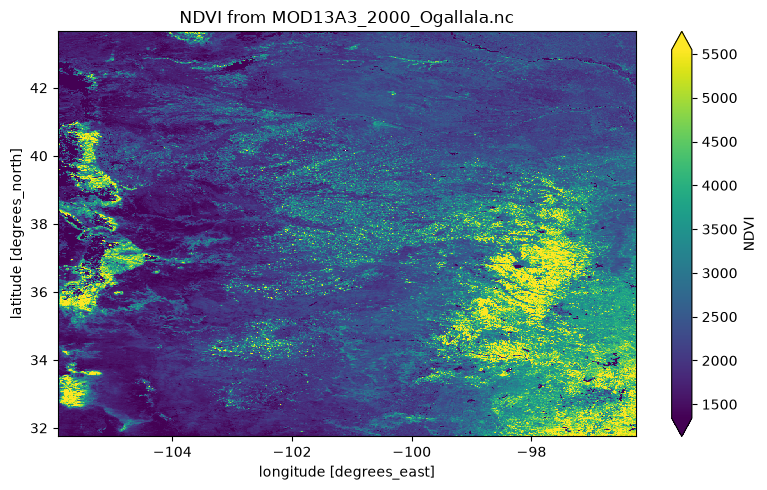

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

nc_path = Path.cwd() / "MOD13A3_2000_Ogallala.nc"
if not nc_path.is_file():
    raise FileNotFoundError(
        f"Dataset file not found: {nc_path}. "
        "This notebook reads only MOD13A3_2000_Ogallala.nc."
    )

print(f"Reading dataset: {nc_path}")

with xr.open_dataset(
    nc_path,
    decode_cf=True,
    mask_and_scale=True,
    chunks="auto",
) as ds:
    with xr.open_dataset(
        nc_path,
        decode_cf=False,
        mask_and_scale=False,
        chunks="auto",
    ) as raw_ds:
        print(ds)

        data_variables = list(ds.data_vars)
        if not data_variables:
            print("No data variables are present in the dataset.")
            raise ValueError("Dataset has no data variables")

        print("\nData variables declared by the file:")
        for name in data_variables:
            variable = ds[name]
            raw_variable = raw_ds[name]
            scale_factor = raw_variable.attrs.get("scale_factor")
            if scale_factor is None:
                scale_factor = raw_variable.encoding.get("scale_factor")
            add_offset = raw_variable.attrs.get("add_offset")
            if add_offset is None:
                add_offset = raw_variable.encoding.get("add_offset")
            fill_value = raw_variable.attrs.get("_FillValue")
            if fill_value is None:
                fill_value = raw_variable.encoding.get("_FillValue")

            if scale_factor is None and add_offset is None:
                scaling_message = (
                    "no scale_factor or add_offset declared; values are used as stored"
                )
            else:
                scaling_message = (
                    f"scale_factor={scale_factor!r}, add_offset={add_offset!r}; "
                    "xarray applied the declared CF metadata"
                )

            print(
                f"  {name}: dims={variable.dims}, dtype={variable.dtype}, "
                f"_FillValue={fill_value!r}; {scaling_message}"
            )

        print("\nCoordinate metadata and coordinate bounds:")
        coordinate_info = {}
        for dimension in ds.dims:
            if dimension not in ds.coords:
                print(f"  {dimension}: no coordinate variable; boundary unavailable")
                continue

            coordinate = ds[dimension]
            values = np.asarray(coordinate.values)
            if coordinate.ndim != 1 or coordinate.dims != (dimension,):
                print(
                    f"  {dimension}: coordinate is not a one-dimensional axis; "
                    "boundary unavailable"
                )
                continue

            finite = np.isfinite(values)
            if not finite.any():
                print(f"  {dimension}: no finite coordinate values; boundary unavailable")
                continue

            finite_values = values[finite]
            differences = np.diff(finite_values)
            monotonic = bool(
                np.all(differences > 0) or np.all(differences < 0)
            )
            coordinate_info[dimension] = {
                "values": values,
                "axis": str(coordinate.attrs.get("axis", "")).upper(),
                "standard_name": str(
                    coordinate.attrs.get("standard_name", "")
                ).lower(),
                "monotonic": monotonic,
            }
            print(
                f"  {dimension}: axis={coordinate.attrs.get('axis', '<not declared>')}, "
                f"standard_name={coordinate.attrs.get('standard_name', '<not declared>')}, "
                f"units={coordinate.attrs.get('units', '<not declared>')}, "
                f"bounds={finite_values.min()} to {finite_values.max()}, "
                f"monotonic={monotonic}"
            )

        def find_dimensions(data_array, axis, standard_name):
            matches = []
            for dimension in data_array.dims:
                info = coordinate_info.get(dimension)
                if info is None:
                    continue
                if info["axis"] == axis or info["standard_name"] == standard_name:
                    matches.append(dimension)
            return matches

        print("\nAvailability by variable:")
        availability = {}
        for name in data_variables:
            variable = ds[name]
            if np.issubdtype(variable.dtype, np.number):
                valid = np.isfinite(variable)
            else:
                valid = variable.notnull()
            valid_count = int(valid.sum().compute())
            total_count = int(variable.size)
            missing_count = total_count - valid_count
            availability[name] = {
                "valid_count": valid_count,
                "missing_count": missing_count,
            }
            if valid_count == 0:
                status = "NO VALUES PRESENT"
            elif missing_count:
                status = f"{missing_count} missing"
            else:
                status = "no missing values"
            print(
                f"  {name}: {valid_count} valid of {total_count}; {status}"
            )

            if valid_count:
                finite_variable = variable.where(valid)
                minimum = finite_variable.min(skipna=True).compute().item()
                maximum = finite_variable.max(skipna=True).compute().item()
                print(f"    decoded finite range: {minimum} to {maximum}")

        target_name = "NDVI"
        if target_name not in data_variables:
            print(
                f"\nNo {target_name} variable is present; "
                f"available variables are {data_variables}. No plot was produced."
            )
        else:
            target = ds[target_name]
            x_dimensions = find_dimensions(target, "X", "longitude")
            y_dimensions = find_dimensions(target, "Y", "latitude")
            time_dimensions = find_dimensions(target, "T", "time")

            if len(x_dimensions) != 1 or len(y_dimensions) != 1:
                print(
                    "\nNDVI plot skipped: the file does not provide exactly one "
                    "X/longitude and one Y/latitude coordinate axis."
                )
            elif len(time_dimensions) > 1:
                print(
                    "\nNDVI plot skipped: the file provides more than one "
                    "T/time coordinate axis."
                )
            else:
                x_dimension = x_dimensions[0]
                y_dimension = y_dimensions[0]
                selection = {}
                if time_dimensions:
                    time_dimension = time_dimensions[0]
                    if ds[time_dimension].size == 0:
                        print("\nNDVI plot skipped: the time coordinate has no values.")
                    else:
                        selection[time_dimension] = 0
                        selected_time = ds[time_dimension].isel(selection).values
                        print(f"\nNDVI time selected from the file: {selected_time}")

                if not time_dimensions or selection:
                    remaining_dimensions = [
                        dimension
                        for dimension in target.dims
                        if dimension not in selection
                    ]
                    if set(remaining_dimensions) != {x_dimension, y_dimension}:
                        print(
                            "NDVI plot skipped: after selecting time, the file "
                            f"still has dimensions {remaining_dimensions}; "
                            "a two-dimensional spatial plot is unavailable."
                        )
                    elif (
                        not coordinate_info[x_dimension]["monotonic"]
                        or not coordinate_info[y_dimension]["monotonic"]
                    ):
                        print(
                            "NDVI plot skipped: the file's spatial coordinates "
                            "are not monotonic, so a reliable boundary is unavailable."
                        )
                    else:
                        plot_data = target.isel(selection).transpose(
                            y_dimension, x_dimension
                        ).load()
                        plot_values = np.asarray(plot_data.values)
                        finite_plot = np.isfinite(plot_values)

                        if not finite_plot.any():
                            print(
                                "No finite NDVI value is present for the selected "
                                "time; no plot was produced."
                            )
                        else:
                            row_indices, column_indices = np.where(finite_plot)
                            y_values = np.asarray(plot_data[y_dimension].values)
                            x_values = np.asarray(plot_data[x_dimension].values)
                            y_available = y_values[row_indices]
                            x_available = x_values[column_indices]
                            x_min = x_available.min()
                            x_max = x_available.max()
                            y_min = y_available.min()
                            y_max = y_available.max()

                            print("NDVI data-available boundary for the selected time:")
                            print(f"  {x_dimension}: {x_min} to {x_max}")
                            print(f"  {y_dimension}: {y_min} to {y_max}")
                            print(
                                f"  selected values: {finite_plot.sum()} valid of "
                                f"{finite_plot.size}; "
                                f"{finite_plot.size - finite_plot.sum()} missing"
                            )

                            rows_with_data = np.flatnonzero(finite_plot.any(axis=1))
                            columns_with_data = np.flatnonzero(finite_plot.any(axis=0))
                            plot_data = plot_data.isel(
                                {
                                    y_dimension: rows_with_data,
                                    x_dimension: columns_with_data,
                                }
                            )
                            plot_artist = plot_data.plot(figsize=(8, 5), robust=True)
                            plot_axis = plot_artist.axes
                            plot_axis.set_xlim(x_min, x_max)
                            plot_axis.set_ylim(y_min, y_max)
                            plot_axis.set_title(
                                f"{target_name} from {nc_path.name}"
                            )
                            plt.tight_layout()
                            plt.show()
